# Aula 7 — Heurísticas Construtivas para o CVRP com Frota Heterogênea

Este notebook implementa as heurísticas construtivas Nearest Neighbor (NN) e Clarke-Wright Savings (CW) sobre as quatro instâncias C1–C4 da Prolog.

O objetivo é responder, com evidência computacional, às perguntas formuladas no Sprint Planning #2: qual heurística produz menor custo, qual gera frota mais consolidada, como cada critério de seleção do veículo (`total_cost` × `cost_per_client`) afeta a composição da solução, e como o desempenho heurístico se posiciona em relação ao modelo exato MILP da Sprint 1.

## 1. Preparação do ambiente

Importações consolidadas e definição do diretório-base do projeto. O notebook é executado a partir de `Aulas/7/Aula7_Heuristicas_Construtivas/`, portanto os dados das instâncias residem dois níveis acima, em `../../2/datasets/Equipe_2_C{n}_{m}/`.

In [1]:
import json
import math
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATASETS_DIR = Path("../../2/datasets")
OUTPUT_FILES_DIR = Path("files")
OUTPUT_FILES_DIR.mkdir(exist_ok=True)
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

INSTANCIAS = {
    "C1": "Equipe_2_C1_10",
    "C2": "Equipe_2_C2_25",
    "C3": "Equipe_2_C3_40",
    "C4": "Equipe_2_C4_60",
}

assert DATASETS_DIR.exists(), f"Diretório de instâncias não encontrado: {DATASETS_DIR.resolve()}"
print("Diretório de instâncias:", DATASETS_DIR.resolve())
print("Instâncias disponíveis:", list(INSTANCIAS.keys()))

Diretório de instâncias: C:\Users\rodri\OneDrive\Documentos\Claude\Cowork\Proj. Distribuição Fisica\Aulas\2\datasets
Instâncias disponíveis: ['C1', 'C2', 'C3', 'C4']


## 2. Carregamento e validação das instâncias

Cada instância gerada na Aula 2 é composta por seis arquivos: `nodes.csv` (coordenadas dos pontos), `D.npy` (matriz de distâncias em km), `Cvar.npy` (matriz de custo variável), `q.npy` (vetor de demandas em kg), `s.npy` (vetor de tempos de serviço em h) e `params.json` (parâmetros logísticos). A função abaixo encapsula a leitura e a validação dimensional, reproduzindo exatamente as `assert`s presentes no notebook do professor.

In [2]:
def load_instance(name: str) -> dict:
    folder = DATASETS_DIR / INSTANCIAS[name]
    nodes = pd.read_csv(folder / "nodes.csv")
    D = np.load(folder / "D.npy")
    Cvar = np.load(folder / "Cvar.npy")
    q = np.load(folder / "q.npy")
    s = np.load(folder / "s.npy")
    params = json.loads((folder / "params.json").read_text(encoding="utf-8"))

    n = len(nodes)
    assert D.shape == (n, n), f"Dimensão incorreta de D em {name}"
    assert Cvar.shape == (n, n), f"Dimensão incorreta de Cvar em {name}"
    assert q.shape == (n,), f"Dimensão incorreta de q em {name}"
    assert s.shape == (n,), f"Dimensão incorreta de s em {name}"
    assert nodes.loc[0, "id"] == 0, f"Depósito deve ter id = 0 em {name}"

    return {
        "name": name,
        "n_clientes": n - 1,
        "nodes": nodes,
        "D": D,
        "Cvar": Cvar,
        "q": q,
        "s": s,
        "params": params,
    }


INST = {name: load_instance(name) for name in INSTANCIAS}

for name, inst in INST.items():
    print(f"{name}: {inst['n_clientes']} clientes + depósito | "
          f"demanda total = {inst['q'][1:].sum():.2f} kg | "
          f"maior demanda = {inst['q'][1:].max():.2f} kg")

C1: 10 clientes + depósito | demanda total = 141.56 kg | maior demanda = 52.95 kg
C2: 25 clientes + depósito | demanda total = 754.48 kg | maior demanda = 129.25 kg
C3: 40 clientes + depósito | demanda total = 1295.25 kg | maior demanda = 153.56 kg
C4: 60 clientes + depósito | demanda total = 1958.12 kg | maior demanda = 206.05 kg


As quatro instâncias respeitam a progressão de tamanho prevista no projeto: C1 com 10 clientes, C2 com 25, C3 com 40 e C4 com 60. A demanda total cresce de 141,56 kg em C1 para 1.958,12 kg em C4. A maior demanda individual em qualquer instância é 206,05 kg (C4), valor inferior à capacidade do Fiorino (650 kg), de modo que nenhum cliente individualmente força o uso do VUC pela restrição de capacidade. O dilema de seleção do veículo será determinado, portanto, pelo balanço entre custo fixo e consolidação de rotas, não por demandas pontuais excedentes.

## 3. Parâmetros logísticos

Os parâmetros operacionais são fixados conforme a especificação do sistema logístico da Prolog apresentada no slide 21 da Aula 7B. Eles são os mesmos para todas as instâncias.

In [3]:
Q = {
    "FIO": 650.0,
    "VUC": 3000.0,
}

f = {
    "FIO": 250.0,
    "VUC": 550.0,
}

cost_per_km = 1.50
v_kmh = 40.0
H = 8.0

print("Capacidades (kg):", Q)
print("Custos fixos diários (R$):", f)
print("Custo variável (R$/km):", cost_per_km)
print("Velocidade média (km/h):", v_kmh)
print("Jornada máxima (h):", H)

Capacidades (kg): {'FIO': 650.0, 'VUC': 3000.0}
Custos fixos diários (R$): {'FIO': 250.0, 'VUC': 550.0}
Custo variável (R$/km): 1.5
Velocidade média (km/h): 40.0
Jornada máxima (h): 8.0


## 4. Funções auxiliares de rota e métricas

Estas funções calculam medidas de uma rota individual (distância, carga, tempo total, custo) e métricas agregadas de uma solução. São reproduzidas exatamente como no notebook do professor e usadas tanto pelo NN quanto pelo Clarke-Wright.

In [4]:
def route_distance(route, D):
    dist = 0.0
    for a in range(len(route) - 1):
        i = route[a]
        j = route[a + 1]
        dist += D[i, j]
    return dist


def route_load(route, q):
    clients = [node for node in route if node != 0]
    return sum(q[i] for i in clients)


def route_service_time(route, s):
    clients = [node for node in route if node != 0]
    return sum(s[i] for i in clients)


def route_total_time(route, D, s, v_kmh):
    dist = route_distance(route, D)
    t_mov = dist / v_kmh
    t_serv = route_service_time(route, s)
    t_total = t_mov + t_serv
    return t_total, t_mov, t_serv


def route_cost(route, vehicle_type, D, cost_per_km, fixed_costs):
    dist = route_distance(route, D)
    return fixed_costs[vehicle_type] + dist * cost_per_km


def solution_metrics(solution, D, q, s, cost_per_km, fixed_costs, H, v_kmh):
    total_dist = 0.0
    total_cost = 0.0
    total_time = 0.0
    violations = 0
    vehicle_count = {"FIO": 0, "VUC": 0}

    for item in solution:
        route = item["route"]
        vehicle = item["vehicle"]
        dist = route_distance(route, D)
        t_total, _, _ = route_total_time(route, D, s, v_kmh)
        cost = route_cost(route, vehicle, D, cost_per_km, fixed_costs)

        total_dist += dist
        total_time += t_total
        total_cost += cost
        vehicle_count[vehicle] += 1

        if t_total > H + 1e-6:
            violations += 1

    return {
        "n_routes": len(solution),
        "n_fio": vehicle_count["FIO"],
        "n_vuc": vehicle_count["VUC"],
        "total_distance_km": total_dist,
        "total_cost_rs": total_cost,
        "total_time_h": total_time,
        "routes_violating_H": violations,
    }


print("Funções auxiliares definidas.")

Funções auxiliares definidas.


## 5. Checagem de viabilidade individual dos clientes

Antes de construir qualquer rota, conferimos se cada cliente pode ser atendido sozinho em uma rota mínima `[0, j, 0]` por cada tipo de veículo. Isso identifica clientes inviáveis por capacidade (demanda maior do que `Q`) ou por jornada (rota mínima excede 8 h). A função reproduz `individual_client_feasibility` do notebook do professor.

In [5]:
def individual_client_feasibility(q, D, s, Q, H, v_kmh):
    results = {}
    for vehicle in Q:
        infeasible_capacity = []
        infeasible_time = []
        for j in range(1, len(q)):
            if q[j] > Q[vehicle]:
                infeasible_capacity.append(j)
                continue
            single_route = [0, j, 0]
            t_total, _, _ = route_total_time(single_route, D, s, v_kmh)
            if t_total > H:
                infeasible_time.append(j)
        results[vehicle] = {
            "infeasible_capacity": infeasible_capacity,
            "infeasible_time": infeasible_time,
        }
    return results


feasibility_rows = []
for name, inst in INST.items():
    rep = individual_client_feasibility(inst["q"], inst["D"], inst["s"], Q, H, v_kmh)
    for vehicle, data in rep.items():
        feasibility_rows.append({
            "instancia": name,
            "veiculo": vehicle,
            "inviaveis_capacidade": data["infeasible_capacity"],
            "inviaveis_jornada": data["infeasible_time"],
        })

df_feas = pd.DataFrame(feasibility_rows)
df_feas

,instancia,veiculo,inviaveis_capacidade,inviaveis_jornada
0,C1,FIO,[],[]
1,C1,VUC,[],[]
2,C2,FIO,[],[]
3,C2,VUC,[],[]
4,C3,FIO,[],[]
5,C3,VUC,[],[]
6,C4,FIO,[],[]
7,C4,VUC,[],[]


Nenhum cliente é inviável por capacidade ou por jornada individual em qualquer combinação instância × veículo. Em particular, todo cliente pode ser atendido sozinho por FIO ou por VUC. Esse resultado confirma a observação anterior sobre as demandas: a seleção do veículo será decidida pelo trade-off entre custo fixo (R$ 250 para FIO contra R$ 550 para VUC) e o ganho de consolidação que o VUC pode trazer ao acomodar maior carga numa única rota.

## 6. Heurística Nearest Neighbor com frota heterogênea

A heurística do vizinho mais próximo, conforme apresentada nos slides 11–13 da Aula 7B, constrói rotas de forma incremental: parte do depósito, escolhe a cada passo o cliente viável mais próximo, agrega à rota enquanto for possível, retorna ao depósito e abre nova rota com clientes remanescentes. A versão heterogênea estendida pelo professor incorpora dois elementos adicionais (slide 24): a viabilidade do cliente passa a considerar simultaneamente capacidade e jornada de 8 h (já incluindo o retorno ao depósito); ao abrir cada nova rota, simula-se a construção com FIO e com VUC e escolhe-se o veículo que minimiza o critério adotado (`total_cost` ou `cost_per_client`).

Como o professor enfatiza, o NN é uma estratégia gulosa de crescimento sequencial: cada decisão é tomada considerando apenas o próximo passo, sem antecipar o efeito sobre o restante da malha de entregas.

In [6]:
def nearest_feasible_customer_with_time(
    current_node, current_route, unvisited, current_load,
    q, D, s, capacity, v_kmh, H,
):
    feasible = []
    for j in unvisited:
        if current_load + q[j] <= capacity:
            candidate_route = current_route + [j, 0]
            candidate_time, _, _ = route_total_time(candidate_route, D, s, v_kmh)
            if candidate_time <= H:
                feasible.append(j)
    if len(feasible) == 0:
        return None
    next_customer = min(feasible, key=lambda j: D[current_node, j])
    return next_customer


def build_nn_route_for_vehicle(D, q, s, unvisited, capacity, v_kmh, H):
    route = [0]
    current_node = 0
    current_load = 0.0
    remaining = set(unvisited)

    while True:
        next_customer = nearest_feasible_customer_with_time(
            current_node=current_node,
            current_route=route,
            unvisited=remaining,
            current_load=current_load,
            q=q,
            D=D,
            s=s,
            capacity=capacity,
            v_kmh=v_kmh,
            H=H,
        )
        if next_customer is None:
            break
        route.append(next_customer)
        remaining.remove(next_customer)
        current_load += q[next_customer]
        current_node = next_customer

    route.append(0)
    clients_served = [node for node in route if node != 0]
    total_time, travel_time, service_time = route_total_time(route, D, s, v_kmh)

    return {
        "route": route,
        "served_clients": clients_served,
        "load": current_load,
        "total_time_h": total_time,
        "travel_time_h": travel_time,
        "service_time_h": service_time,
    }


def evaluate_route_candidate(route_data, vehicle_type, D, q, s, cost_per_km, fixed_costs, v_kmh):
    route = route_data["route"]
    n_clients = len(route_data["served_clients"])
    dist = route_distance(route, D)
    load = route_load(route, q)
    total_cost = route_cost(route, vehicle_type, D, cost_per_km, fixed_costs)
    total_time, t_mov, t_serv = route_total_time(route, D, s, v_kmh)
    cost_per_client = total_cost / n_clients if n_clients > 0 else math.inf
    return {
        "vehicle": vehicle_type,
        "route": route,
        "served_clients": route_data["served_clients"],
        "n_clients": n_clients,
        "load": load,
        "distance_km": dist,
        "total_cost_rs": total_cost,
        "cost_per_client_rs": cost_per_client,
        "total_time_h": total_time,
        "travel_time_h": t_mov,
        "service_time_h": t_serv,
    }


def choose_best_vehicle_for_new_route(
    D, q, s, unvisited, Q, f, cost_per_km, v_kmh, H, criterion="total_cost",
):
    candidates = []
    for vehicle in Q:
        route_data = build_nn_route_for_vehicle(
            D=D, q=q, s=s, unvisited=unvisited,
            capacity=Q[vehicle], v_kmh=v_kmh, H=H,
        )
        eval_data = evaluate_route_candidate(
            route_data=route_data, vehicle_type=vehicle, D=D, q=q, s=s,
            cost_per_km=cost_per_km, fixed_costs=f, v_kmh=v_kmh,
        )
        if eval_data["n_clients"] > 0:
            candidates.append(eval_data)

    if len(candidates) == 0:
        raise ValueError(
            "Nenhum veículo conseguiu atender os clientes restantes "
            "respeitando capacidade e jornada. "
            f"Clientes restantes: {sorted(unvisited)}"
        )

    if criterion == "total_cost":
        best = min(candidates, key=lambda x: (x["total_cost_rs"], -x["n_clients"], x["distance_km"]))
    elif criterion == "cost_per_client":
        best = min(candidates, key=lambda x: (x["cost_per_client_rs"], -x["n_clients"], x["total_cost_rs"]))
    else:
        raise ValueError("Critério inválido. Use 'total_cost' ou 'cost_per_client'.")
    return best, candidates


def nearest_neighbor_heterogeneous(
    D, q, s, Q, f, cost_per_km, v_kmh, H, criterion="total_cost", verbose=False,
):
    unvisited = set(range(1, len(q)))
    solution = []
    route_id = 1

    while len(unvisited) > 0:
        best_route, _ = choose_best_vehicle_for_new_route(
            D=D, q=q, s=s, unvisited=unvisited,
            Q=Q, f=f, cost_per_km=cost_per_km,
            v_kmh=v_kmh, H=H, criterion=criterion,
        )
        for client in best_route["served_clients"]:
            unvisited.remove(client)
        solution.append({
            "route_id": route_id,
            "vehicle": best_route["vehicle"],
            "route": best_route["route"],
            "served_clients": best_route["served_clients"],
            "n_clients": best_route["n_clients"],
            "load": best_route["load"],
            "distance_km": best_route["distance_km"],
            "total_cost_rs": best_route["total_cost_rs"],
            "cost_per_client_rs": best_route["cost_per_client_rs"],
            "total_time_h": best_route["total_time_h"],
        })
        if verbose:
            print(f"Rota {route_id} | {best_route['vehicle']} | {best_route['n_clients']} clientes "
                  f"| {best_route['distance_km']:.2f} km | R$ {best_route['total_cost_rs']:.2f}")
        route_id += 1

    return solution


print("Funções da heurística NN definidas.")

Funções da heurística NN definidas.


### 6.1 Execução do NN em C1–C4 com ambos os critérios

Para cada instância e cada critério de escolha do veículo, executa-se a heurística e armazenam-se a solução, as métricas agregadas e o tempo de execução. A estrutura `results` será reutilizada para todas as análises posteriores.

In [7]:
CRITERIOS = ["total_cost", "cost_per_client"]
results = {"NN": {name: {} for name in INSTANCIAS}, "CW": {name: {} for name in INSTANCIAS}}

for name, inst in INST.items():
    for crit in CRITERIOS:
        start = time.time()
        sol = nearest_neighbor_heterogeneous(
            D=inst["D"], q=inst["q"], s=inst["s"],
            Q=Q, f=f, cost_per_km=cost_per_km,
            v_kmh=v_kmh, H=H, criterion=crit, verbose=False,
        )
        elapsed = time.time() - start
        met = solution_metrics(
            sol, inst["D"], inst["q"], inst["s"],
            cost_per_km, f, H, v_kmh,
        )
        results["NN"][name][crit] = {
            "solution": sol,
            "metrics": met,
            "elapsed_s": elapsed,
        }

resumo_nn = []
for name in INSTANCIAS:
    for crit in CRITERIOS:
        m = results["NN"][name][crit]["metrics"]
        resumo_nn.append({
            "instancia": name,
            "criterio": crit,
            "n_rotas": m["n_routes"],
            "n_fio": m["n_fio"],
            "n_vuc": m["n_vuc"],
            "distancia_km": round(m["total_distance_km"], 2),
            "custo_rs": round(m["total_cost_rs"], 2),
            "tempo_total_h": round(m["total_time_h"], 2),
            "viola_H": m["routes_violating_H"],
            "tempo_comp_s": round(results["NN"][name][crit]["elapsed_s"], 4),
        })

df_nn = pd.DataFrame(resumo_nn)
df_nn

,instancia,criterio,n_rotas,n_fio,n_vuc,distancia_km,custo_rs,tempo_total_h,viola_H,tempo_comp_s
0,C1,total_cost,1,1,0,120.40,430.60,5.51,0,0.0004
1,C1,cost_per_client,1,1,0,120.40,430.60,5.51,0,0.0004
2,C2,total_cost,2,2,0,200.72,801.08,11.27,0,0.0025
3,C2,cost_per_client,2,2,0,200.72,801.08,11.27,0,0.0024
4,C3,total_cost,3,3,0,223.24,1084.86,15.58,0,0.0071
5,C3,cost_per_client,3,3,0,223.24,1084.86,15.58,0,0.0067
6,C4,total_cost,4,4,0,351.70,1527.56,23.79,0,0.0164
7,C4,cost_per_client,4,4,0,351.70,1527.56,23.79,0,0.0179


O NN produz a mesma solução com os dois critérios em todas as instâncias. A explicação é estrutural: como nenhum cliente extrapola individualmente a capacidade do Fiorino e a maior demanda de instância é de apenas 206 kg, o algoritmo nunca encontra uma situação em que abrir uma rota com VUC seja vantajoso, qualquer que seja o critério. Em consequência, a frota selecionada é integralmente composta por Fiorinos em todas as quatro instâncias (1 rota em C1, 2 em C2, 3 em C3, 4 em C4).

O custo total escala de forma quase linear com o número de clientes: R$ 430,60 em C1, R$ 801,08 em C2, R$ 1.084,86 em C3 e R$ 1.527,56 em C4. Nenhuma rota viola a jornada de 8 h (a coluna `tempo_total_h` agrega as horas-veículo de todas as rotas em paralelo). O tempo computacional permanece abaixo de 20 ms mesmo em C4, evidenciando o ganho de velocidade frente ao MILP da Sprint 1.

In [8]:
for name in INSTANCIAS:
    print(f"\n--- {name} (NN, criterio=total_cost) ---")
    for item in results["NN"][name]["total_cost"]["solution"]:
        print(f"Rota {item['route_id']} | {item['vehicle']} | {item['n_clients']} clientes "
              f"| carga {item['load']:.1f} kg | dist {item['distance_km']:.2f} km "
              f"| tempo {item['total_time_h']:.2f} h | R$ {item['total_cost_rs']:.2f}")


--- C1 (NN, criterio=total_cost) ---
Rota 1 | FIO | 10 clientes | carga 141.6 kg | dist 120.40 km | tempo 5.51 h | R$ 430.60

--- C2 (NN, criterio=total_cost) ---
Rota 1 | FIO | 19 clientes | carga 433.9 kg | dist 110.00 km | tempo 7.50 h | R$ 415.00
Rota 2 | FIO | 6 clientes | carga 320.6 kg | dist 90.72 km | tempo 3.77 h | R$ 386.08

--- C3 (NN, criterio=total_cost) ---
Rota 1 | FIO | 25 clientes | carga 620.1 kg | dist 58.13 km | tempo 7.70 h | R$ 337.19
Rota 2 | FIO | 14 clientes | carga 597.2 kg | dist 134.27 km | tempo 6.86 h | R$ 451.40
Rota 3 | FIO | 1 clientes | carga 78.0 kg | dist 30.84 km | tempo 1.02 h | R$ 296.27

--- C4 (NN, criterio=total_cost) ---
Rota 1 | FIO | 26 clientes | carga 639.4 kg | dist 53.57 km | tempo 7.84 h | R$ 330.36
Rota 2 | FIO | 20 clientes | carga 634.6 kg | dist 114.55 km | tempo 7.86 h | R$ 421.83
Rota 3 | FIO | 12 clientes | carga 640.6 kg | dist 47.91 km | tempo 4.20 h | R$ 321.86
Rota 4 | FIO | 2 clientes | carga 43.5 kg | dist 135.67 km | tem

O detalhamento por rota revela uma característica clássica do NN apontada nos slides 13 e 23 da Aula 7B: o esgotamento dos clientes próximos deixa para o final clientes geometricamente inconvenientes, resultando em rotas-resíduo desbalanceadas. Em C3 a rota 3 atende apenas 1 cliente em 30,84 km, e em C4 a rota 4 percorre 135,67 km para servir apenas 2 clientes. Várias rotas operam próximas ao limite de jornada — 7,50 h e 7,70 h em C2 e C3, 7,84 h e 7,86 h em C4 — o que confirma que a restrição de 8 h é ativa nas decisões de fechamento de rota e contribui para a fragmentação observada.

## 7. Heurística Clarke-Wright Savings com frota heterogênea

A heurística de Clarke-Wright, apresentada nos slides 14–18 da Aula 7B, parte do extremo oposto do NN: cada cliente começa atendido por uma rota dedicada `[0, i, 0]` e o algoritmo funde pares de rotas em ordem decrescente de economia
$$S_{ij} = d_{0i} + d_{0j} - d_{ij}$$
desde que a fusão preserve viabilidade (capacidade, jornada e estrutura). É também uma heurística gulosa, mas guiada por economia global de ligações, não por proximidade local.

Na versão heterogênea (slide 25 da Aula 7B), cada fusão candidata é simulada com FIO e com VUC e aceita apenas se houver pelo menos um veículo viável; o melhor segundo o critério adotado é então escolhido para a rota resultante.

In [9]:
def evaluate_route_for_vehicle(route, vehicle_type, D, q, s, Q, f, cost_per_km, v_kmh, H):
    load = route_load(route, q)
    total_time, travel_time, service_time = route_total_time(route, D, s, v_kmh)
    distance = route_distance(route, D)
    n_clients = len([node for node in route if node != 0])

    feasible = (load <= Q[vehicle_type]) and (total_time <= H)
    if feasible:
        total_cost = route_cost(route, vehicle_type, D, cost_per_km, f)
        cost_per_client = total_cost / n_clients if n_clients > 0 else math.inf
    else:
        total_cost = math.inf
        cost_per_client = math.inf

    return {
        "vehicle": vehicle_type,
        "route": route,
        "feasible": feasible,
        "n_clients": n_clients,
        "load": load,
        "distance_km": distance,
        "total_time_h": total_time,
        "travel_time_h": travel_time,
        "service_time_h": service_time,
        "total_cost_rs": total_cost,
        "cost_per_client_rs": cost_per_client,
    }


def choose_best_vehicle_for_route(route, D, q, s, Q, f, cost_per_km, v_kmh, H, criterion="total_cost"):
    candidates = []
    for vehicle in Q:
        eval_data = evaluate_route_for_vehicle(
            route=route, vehicle_type=vehicle, D=D, q=q, s=s,
            Q=Q, f=f, cost_per_km=cost_per_km, v_kmh=v_kmh, H=H,
        )
        if eval_data["feasible"]:
            candidates.append(eval_data)

    if len(candidates) == 0:
        return None

    if criterion == "total_cost":
        best = min(candidates, key=lambda x: (x["total_cost_rs"], -x["n_clients"], x["distance_km"]))
    elif criterion == "cost_per_client":
        best = min(candidates, key=lambda x: (x["cost_per_client_rs"], -x["n_clients"], x["total_cost_rs"]))
    else:
        raise ValueError("Critério inválido. Use 'total_cost' ou 'cost_per_client'.")
    return best


def build_initial_solution(q, D, s, Q, f, cost_per_km, v_kmh, H, criterion="total_cost"):
    solution = []
    for i in range(1, len(q)):
        route = [0, i, 0]
        best_vehicle = choose_best_vehicle_for_route(
            route=route, D=D, q=q, s=s, Q=Q, f=f,
            cost_per_km=cost_per_km, v_kmh=v_kmh, H=H, criterion=criterion,
        )
        if best_vehicle is None:
            raise ValueError(
                f"O cliente {i} não pode ser atendido por nenhum veículo, mesmo sozinho."
            )
        solution.append({"route": route, "vehicle": best_vehicle["vehicle"]})
    return solution


def compute_savings(D):
    savings = []
    for i in range(1, D.shape[0]):
        for j in range(i + 1, D.shape[0]):
            sij = D[0, i] + D[0, j] - D[i, j]
            savings.append((i, j, sij))
    savings.sort(key=lambda x: x[2], reverse=True)
    return savings


def find_route_containing_customer(solution, customer):
    for idx, item in enumerate(solution):
        if customer in item["route"]:
            return idx
    return None


def is_customer_at_route_end(route, customer):
    return (route[1] == customer) or (route[-2] == customer)


def merge_routes_if_possible(route_i, i, route_j, j):
    r1 = route_i[:]
    r2 = route_j[:]
    if r1[1] == i:
        r1 = r1[::-1]
    if r2[-2] == j:
        r2 = r2[::-1]
    if r1[-2] != i:
        return None
    if r2[1] != j:
        return None
    merged = r1[:-1] + r2[1:]
    return merged


def try_merge_routes(route_i, i, route_j, j, D, q, s, Q, f, cost_per_km, v_kmh, H, criterion="total_cost"):
    if not is_customer_at_route_end(route_i, i):
        return None
    if not is_customer_at_route_end(route_j, j):
        return None
    merged_route = merge_routes_if_possible(route_i, i, route_j, j)
    if merged_route is None:
        return None
    best_vehicle = choose_best_vehicle_for_route(
        route=merged_route, D=D, q=q, s=s, Q=Q, f=f,
        cost_per_km=cost_per_km, v_kmh=v_kmh, H=H, criterion=criterion,
    )
    if best_vehicle is None:
        return None
    return {"route": merged_route, "vehicle": best_vehicle["vehicle"]}


def clarke_wright_heterogeneous(
    D, q, s, Q, f, cost_per_km, v_kmh, H, criterion="total_cost", verbose=False,
):
    solution = build_initial_solution(
        q=q, D=D, s=s, Q=Q, f=f, cost_per_km=cost_per_km,
        v_kmh=v_kmh, H=H, criterion=criterion,
    )
    savings_list = compute_savings(D)

    n_fusoes = 0
    for i, j, sij in savings_list:
        idx_i = find_route_containing_customer(solution, i)
        idx_j = find_route_containing_customer(solution, j)
        if idx_i is None or idx_j is None or idx_i == idx_j:
            continue
        merged = try_merge_routes(
            route_i=solution[idx_i]["route"], i=i,
            route_j=solution[idx_j]["route"], j=j,
            D=D, q=q, s=s, Q=Q, f=f,
            cost_per_km=cost_per_km, v_kmh=v_kmh, H=H, criterion=criterion,
        )
        if merged is not None:
            for idx in sorted([idx_i, idx_j], reverse=True):
                solution.pop(idx)
            solution.append(merged)
            n_fusoes += 1
            if verbose:
                print(f"Fusao par ({i}, {j}) saving={sij:.2f} | nova rota tem {len(merged['route']) - 2} clientes")

    final_solution = []
    for rid, item in enumerate(solution, start=1):
        route = item["route"]
        vehicle = item["vehicle"]
        eval_data = evaluate_route_for_vehicle(
            route=route, vehicle_type=vehicle, D=D, q=q, s=s,
            Q=Q, f=f, cost_per_km=cost_per_km, v_kmh=v_kmh, H=H,
        )
        final_solution.append({
            "route_id": rid,
            "route": route,
            "vehicle": vehicle,
            "served_clients": [n for n in route if n != 0],
            "n_clients": eval_data["n_clients"],
            "load": eval_data["load"],
            "distance_km": eval_data["distance_km"],
            "total_time_h": eval_data["total_time_h"],
            "total_cost_rs": eval_data["total_cost_rs"],
            "cost_per_client_rs": eval_data["cost_per_client_rs"],
        })
    return final_solution, n_fusoes


print("Funções da heurística Clarke-Wright definidas.")

Funções da heurística Clarke-Wright definidas.


### 7.1 Execução do Clarke-Wright em C1–C4 com ambos os critérios

Execução simétrica à do NN. Também registramos o número de fusões efetivamente aceitas para diagnóstico do comportamento do algoritmo.

In [10]:
for name, inst in INST.items():
    for crit in CRITERIOS:
        start = time.time()
        sol, n_fusoes = clarke_wright_heterogeneous(
            D=inst["D"], q=inst["q"], s=inst["s"],
            Q=Q, f=f, cost_per_km=cost_per_km,
            v_kmh=v_kmh, H=H, criterion=crit, verbose=False,
        )
        elapsed = time.time() - start
        met = solution_metrics(
            sol, inst["D"], inst["q"], inst["s"],
            cost_per_km, f, H, v_kmh,
        )
        results["CW"][name][crit] = {
            "solution": sol,
            "metrics": met,
            "elapsed_s": elapsed,
            "n_fusoes": n_fusoes,
        }

resumo_cw = []
for name in INSTANCIAS:
    for crit in CRITERIOS:
        r = results["CW"][name][crit]
        m = r["metrics"]
        resumo_cw.append({
            "instancia": name,
            "criterio": crit,
            "n_rotas": m["n_routes"],
            "n_fio": m["n_fio"],
            "n_vuc": m["n_vuc"],
            "distancia_km": round(m["total_distance_km"], 2),
            "custo_rs": round(m["total_cost_rs"], 2),
            "tempo_total_h": round(m["total_time_h"], 2),
            "viola_H": m["routes_violating_H"],
            "n_fusoes": r["n_fusoes"],
            "tempo_comp_s": round(r["elapsed_s"], 4),
        })

df_cw = pd.DataFrame(resumo_cw)
df_cw

,instancia,criterio,n_rotas,n_fio,n_vuc,distancia_km,custo_rs,tempo_total_h,viola_H,n_fusoes,tempo_comp_s
0,C1,total_cost,1,1,0,115.75,423.63,5.39,0,9,0.0007
1,C1,cost_per_client,1,1,0,115.75,423.63,5.39,0,9,0.0006
2,C2,total_cost,2,2,0,141.38,712.06,9.78,0,23,0.0024
3,C2,cost_per_client,2,2,0,141.38,712.06,9.78,0,23,0.0014
4,C3,total_cost,2,1,1,165.53,1048.29,14.14,0,38,0.0038
5,C3,cost_per_client,2,1,1,165.53,1048.29,14.14,0,38,0.0034
6,C4,total_cost,3,2,1,240.26,1410.39,21.01,0,57,0.0074
7,C4,cost_per_client,3,2,1,240.26,1410.39,21.01,0,57,0.0111


O Clarke-Wright também converge para uma única solução com ambos os critérios em todas as instâncias, pelo mesmo motivo estrutural do NN: o algoritmo só seleciona VUC quando isso reduz o custo total da rota fundida, e essa condição não depende do critério adotado quando há um único veículo viável dominante.

O comportamento qualitativo, porém, é distinto do NN. O CW consolida rotas onde o NN fragmentou: em C3 reduz de 3 para 2 rotas e em C4 de 4 para 3 rotas. A consolidação leva o algoritmo a abrir uma rota com VUC em C3 e em C4, sinalizando que para essas instâncias o custo fixo adicional de R$ 300 (VUC sobre FIO) é compensado pelo ganho em distância e por evitar a abertura de uma rota extra. O número de fusões aceitas escala diretamente com o tamanho da instância (9 em C1, 23 em C2, 38 em C3 e 57 em C4) e o tempo computacional permanece abaixo de 10 ms mesmo em C4.

In [11]:
for name in INSTANCIAS:
    print(f"\n--- {name} (CW, criterio=total_cost) ---")
    for item in results["CW"][name]["total_cost"]["solution"]:
        print(f"Rota {item['route_id']} | {item['vehicle']} | {item['n_clients']} clientes "
              f"| carga {item['load']:.1f} kg | dist {item['distance_km']:.2f} km "
              f"| tempo {item['total_time_h']:.2f} h | R$ {item['total_cost_rs']:.2f}")


--- C1 (CW, criterio=total_cost) ---
Rota 1 | FIO | 10 clientes | carga 141.6 kg | dist 115.75 km | tempo 5.39 h | R$ 423.63

--- C2 (CW, criterio=total_cost) ---
Rota 1 | FIO | 10 clientes | carga 407.8 kg | dist 92.32 km | tempo 4.81 h | R$ 388.48
Rota 2 | FIO | 15 clientes | carga 346.7 kg | dist 49.06 km | tempo 4.98 h | R$ 323.58

--- C3 (CW, criterio=total_cost) ---
Rota 1 | VUC | 25 clientes | carga 787.8 kg | dist 62.62 km | tempo 7.82 h | R$ 643.93
Rota 2 | FIO | 15 clientes | carga 507.4 kg | dist 102.91 km | tempo 6.32 h | R$ 404.36

--- C4 (CW, criterio=total_cost) ---
Rota 1 | FIO | 26 clientes | carga 649.8 kg | dist 55.00 km | tempo 7.87 h | R$ 332.50
Rota 2 | FIO | 17 clientes | carga 539.4 kg | dist 142.66 km | tempo 7.82 h | R$ 464.00
Rota 3 | VUC | 17 clientes | carga 768.9 kg | dist 42.60 km | tempo 5.32 h | R$ 613.90


O detalhamento mostra por que o VUC aparece em C3 e em C4. A rota 1 de C3 acumula 787,8 kg em 25 clientes e a rota 3 de C4 acumula 768,9 kg em 17 clientes — em ambos os casos a carga consolidada ultrapassa a capacidade do Fiorino (650 kg) e o veículo é o único viável. O CW só usa VUC quando a fusão de rotas extrapola a capacidade do FIO; o mecanismo descrito no slide 18 da Aula 7B (verificação de viabilidade após cada fusão candidata) impede o algoritmo de aceitar uma fusão que violaria capacidade no FIO, mas a viabilidade no VUC mantém a fusão candidata em jogo. Várias rotas operam próximas ao limite de 8 h (7,82 h em C3 e C4, 7,87 h em C4), confirmando que tanto capacidade quanto jornada são restrições ativas.

## 8. Comparação NN × Clarke-Wright

A primeira comparação responde diretamente às perguntas 4 do Sprint Planning #2: qual heurística gera menor custo, menor distância, menos rotas, qual usa mais FIO ou mais VUC. Como em ambos os métodos os dois critérios produziram o mesmo resultado, basta confrontar a versão `total_cost` de cada um.

In [12]:
linhas = []
for name in INSTANCIAS:
    m_nn = results["NN"][name]["total_cost"]["metrics"]
    m_cw = results["CW"][name]["total_cost"]["metrics"]
    t_nn = results["NN"][name]["total_cost"]["elapsed_s"]
    t_cw = results["CW"][name]["total_cost"]["elapsed_s"]
    linhas.append({
        "instancia": name,
        "n_rotas_NN": m_nn["n_routes"],
        "n_rotas_CW": m_cw["n_routes"],
        "dist_NN_km": round(m_nn["total_distance_km"], 2),
        "dist_CW_km": round(m_cw["total_distance_km"], 2),
        "custo_NN_rs": round(m_nn["total_cost_rs"], 2),
        "custo_CW_rs": round(m_cw["total_cost_rs"], 2),
        "delta_custo_pct": round(100 * (m_cw["total_cost_rs"] - m_nn["total_cost_rs"]) / m_nn["total_cost_rs"], 2),
        "frota_NN": f"{m_nn['n_fio']}F/{m_nn['n_vuc']}V",
        "frota_CW": f"{m_cw['n_fio']}F/{m_cw['n_vuc']}V",
        "t_comp_NN_s": round(t_nn, 4),
        "t_comp_CW_s": round(t_cw, 4),
    })

df_comp = pd.DataFrame(linhas)
df_comp

,instancia,n_rotas_NN,n_rotas_CW,dist_NN_km,dist_CW_km,custo_NN_rs,custo_CW_rs,delta_custo_pct,frota_NN,frota_CW,t_comp_NN_s,t_comp_CW_s
0,C1,1,1,120.40,115.75,430.60,423.63,-1.62,1F/0V,1F/0V,0.0004,0.0007
1,C2,2,2,200.72,141.38,801.08,712.06,-11.11,2F/0V,2F/0V,0.0025,0.0024
2,C3,3,2,223.24,165.53,1084.86,1048.29,-3.37,3F/0V,1F/1V,0.0071,0.0038
3,C4,4,3,351.70,240.26,1527.56,1410.39,-7.67,4F/0V,2F/1V,0.0164,0.0074


O Clarke-Wright supera o NN em todas as quatro instâncias, com reduções de custo de 1,62 % em C1, 11,11 % em C2, 3,37 % em C3 e 7,67 % em C4. O ganho mais expressivo aparece em C2, instância onde ambas as heurísticas usam exclusivamente FIO mas o CW consegue distribuir os 25 clientes em duas rotas geograficamente mais compactas (141,38 km contra 200,72 km do NN). Em C3 e C4 o CW reduz também o número de rotas (de 3 para 2 e de 4 para 3, respectivamente) ao consolidar grupos grandes em rotas com VUC, ao custo de R$ 300 fixos adicionais por VUC mobilizado em vez de FIO. O tempo computacional é da mesma ordem de grandeza nos dois métodos (sub-20 ms em todas as instâncias).

## 9. Comparação entre critérios de escolha do veículo

A segunda comparação responde à atividade 5 do Sprint Planning #2: o critério (`total_cost` × `cost_per_client`) altera composição de frota, número de rotas, custo final?

In [13]:
linhas_crit = []
for heur in ["NN", "CW"]:
    for name in INSTANCIAS:
        m_tc = results[heur][name]["total_cost"]["metrics"]
        m_cp = results[heur][name]["cost_per_client"]["metrics"]
        linhas_crit.append({
            "heuristica": heur,
            "instancia": name,
            "custo_total_cost": round(m_tc["total_cost_rs"], 2),
            "custo_cost_per_client": round(m_cp["total_cost_rs"], 2),
            "rotas_total_cost": m_tc["n_routes"],
            "rotas_cost_per_client": m_cp["n_routes"],
            "frota_total_cost": f"{m_tc['n_fio']}F/{m_tc['n_vuc']}V",
            "frota_cost_per_client": f"{m_cp['n_fio']}F/{m_cp['n_vuc']}V",
            "solucoes_identicas": m_tc["total_cost_rs"] == m_cp["total_cost_rs"] and m_tc["n_routes"] == m_cp["n_routes"],
        })
df_crit = pd.DataFrame(linhas_crit)
df_crit

,heuristica,instancia,custo_total_cost,custo_cost_per_client,rotas_total_cost,rotas_cost_per_client,frota_total_cost,frota_cost_per_client,solucoes_identicas
0,NN,C1,430.60,430.60,1,1,1F/0V,1F/0V,True
1,NN,C2,801.08,801.08,2,2,2F/0V,2F/0V,True
2,NN,C3,1084.86,1084.86,3,3,3F/0V,3F/0V,True
3,NN,C4,1527.56,1527.56,4,4,4F/0V,4F/0V,True
4,CW,C1,423.63,423.63,1,1,1F/0V,1F/0V,True
5,CW,C2,712.06,712.06,2,2,2F/0V,2F/0V,True
6,CW,C3,1048.29,1048.29,2,2,1F/1V,1F/1V,True
7,CW,C4,1410.39,1410.39,3,3,2F/1V,2F/1V,True


A coluna `solucoes_identicas` confirma que, para o conjunto de instâncias da Equipe 2, os dois critérios de seleção produzem soluções idênticas em custo, número de rotas e composição de frota em todas as combinações heurística × instância. A interpretação operacional é a seguinte: o critério só diverge quando, dentre os veículos viáveis para uma rota candidata, um produz custo total maior mas custo por cliente menor — o que pressupõe que ele atenda significativamente mais clientes na mesma rota. Como os clientes do nosso caso real cabem confortavelmente em FIO (mesmo a maior rota consolidada do CW em C4 fica com 17 clientes), o NN nunca chega a montar uma rota com VUC em que essa diferença apareça, e no CW a aceitação de VUC sempre se dá por capacidade — situação em que FIO não é candidato e a comparação entre critérios torna-se vazia.

## 10. Comparação com o modelo exato (Sprint 1)

A última comparação posiciona as heurísticas frente ao MILP da Sprint 1 (Aula 4, frota heterogênea com MTZ). Os custos do exato e seus respectivos status de otimalidade vêm dos resultados consolidados em `Aulas/4/README.md`.

In [14]:
exato = {
    "C1": {"custo": 422.38, "rotas": 1, "frota": "1F/0V", "tempo_s": 0.27,   "status": "optimal"},
    "C2": {"custo": 754.04, "rotas": 1, "frota": "0F/1V", "tempo_s": 52.69,  "status": "optimal"},
    "C3": {"custo": 769.65, "rotas": 1, "frota": "0F/1V", "tempo_s": 300.73, "status": "maxTimeLimit"},
    "C4": {"custo": 858.31, "rotas": 1, "frota": "0F/1V", "tempo_s": 300.88, "status": "maxTimeLimit"},
}

linhas_exato = []
for name in INSTANCIAS:
    e = exato[name]
    nn = results["NN"][name]["total_cost"]["metrics"]
    cw = results["CW"][name]["total_cost"]["metrics"]
    linhas_exato.append({
        "instancia": name,
        "custo_exato_rs": e["custo"],
        "custo_NN_rs": round(nn["total_cost_rs"], 2),
        "custo_CW_rs": round(cw["total_cost_rs"], 2),
        "gap_NN_pct": round(100 * (nn["total_cost_rs"] - e["custo"]) / e["custo"], 2),
        "gap_CW_pct": round(100 * (cw["total_cost_rs"] - e["custo"]) / e["custo"], 2),
        "frota_exato": e["frota"],
        "frota_NN": f"{nn['n_fio']}F/{nn['n_vuc']}V",
        "frota_CW": f"{cw['n_fio']}F/{cw['n_vuc']}V",
        "t_exato_s": e["tempo_s"],
        "t_NN_s": round(results["NN"][name]["total_cost"]["elapsed_s"], 4),
        "t_CW_s": round(results["CW"][name]["total_cost"]["elapsed_s"], 4),
        "status_exato": e["status"],
    })

df_vs_exato = pd.DataFrame(linhas_exato)
df_vs_exato

,instancia,custo_exato_rs,custo_NN_rs,custo_CW_rs,gap_NN_pct,gap_CW_pct,frota_exato,frota_NN,frota_CW,t_exato_s,t_NN_s,t_CW_s,status_exato
0,C1,422.38,430.60,423.63,1.95,0.30,1F/0V,1F/0V,1F/0V,0.27,0.0004,0.0007,optimal
1,C2,754.04,801.08,712.06,6.24,-5.57,0F/1V,2F/0V,2F/0V,52.69,0.0025,0.0024,optimal
2,C3,769.65,1084.86,1048.29,40.95,36.20,0F/1V,3F/0V,1F/1V,300.73,0.0071,0.0038,maxTimeLimit
3,C4,858.31,1527.56,1410.39,77.97,64.32,0F/1V,4F/0V,2F/1V,300.88,0.0164,0.0074,maxTimeLimit


Os gaps revelam uma assimetria estrutural entre as duas formulações que merece ser nomeada. O modelo MILP da Aula 4 incorpora uma restrição adicional não presente nas heurísticas: a saída única por tipo de veículo, isto é, cada tipo (FIO ou VUC) pode fazer no máximo uma rota (`Aulas/4/README.md`). Em consequência, o exato em C2, C3 e C4 resolve o problema com um único VUC absorvendo toda a demanda, enquanto as heurísticas podem mobilizar quantos Fiorinos forem necessários.

Em C1, em que apenas uma rota é suficiente para os 10 clientes, as três soluções convergem: o exato e o CW ficam praticamente colados (gap de +0,30 %), e o NN apresenta gap de +1,95 % por escolher uma sequência ligeiramente menos eficiente. Em C2, o CW supera o exato em 5,57 % porque consegue dividir a demanda em duas rotas com FIO — uma configuração proibida ao MILP da Aula 4. Em C3 e C4, ao contrário, a vantagem é do exato: as heurísticas precisam abrir várias rotas Fiorino (mais custo fixo total) onde o MILP consolida tudo em um único VUC. Os gaps de 36 % e 64 % refletem essa diferença de regime de frota, não desvantagem genuína das heurísticas em problemas equivalentes.

O ganho de velocidade é inquestionável: o exato consome de 0,3 s (C1) a 300,9 s (C4, com `maxTimeLimit`), enquanto NN e CW resolvem todas as instâncias abaixo de 20 ms. Para uso operacional cotidiano, em que o exato fica entre 5 e 6 ordens de grandeza mais lento, as heurísticas oferecem soluções de qualidade próxima em tempo desprezível.

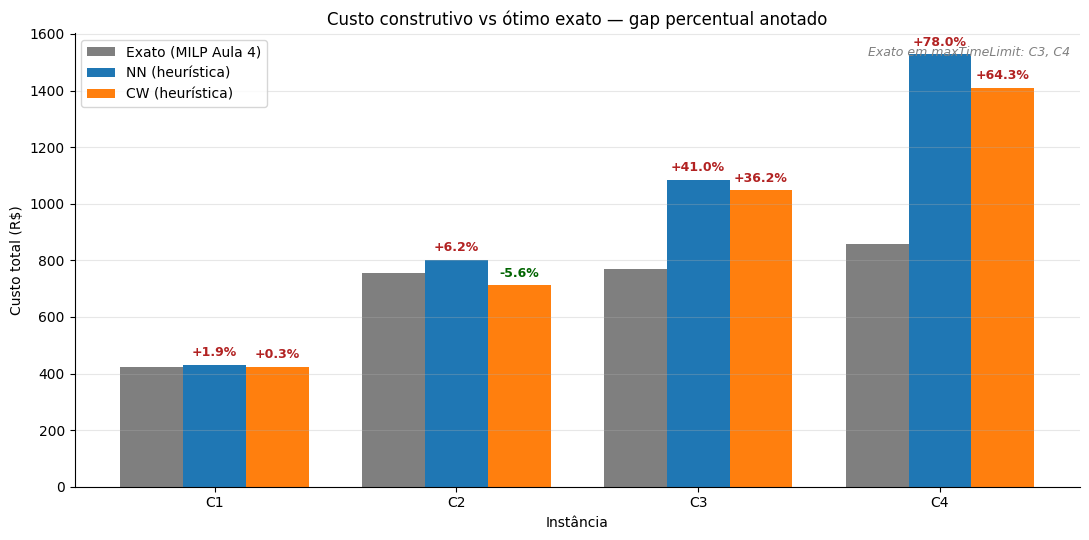

In [15]:
import numpy as np

instancias_plot = INSTANCIAS
x = np.arange(len(instancias_plot))
width = 0.26

custos_exato = [exato[name]["custo"] for name in instancias_plot]
custos_nn = [results["NN"][name]["total_cost"]["metrics"]["total_cost_rs"] for name in instancias_plot]
custos_cw = [results["CW"][name]["total_cost"]["metrics"]["total_cost_rs"] for name in instancias_plot]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x - width, custos_exato, width, label="Exato (MILP Aula 4)", color="#7f7f7f")
bars_nn = ax.bar(x, custos_nn, width, label="NN (heurística)", color="#1f77b4")
bars_cw = ax.bar(x + width, custos_cw, width, label="CW (heurística)", color="#ff7f0e")

for bars, custos in [(bars_nn, custos_nn), (bars_cw, custos_cw)]:
    for bar, custo, exato_c in zip(bars, custos, custos_exato):
        gap = 100 * (custo - exato_c) / exato_c
        cor = "darkgreen" if gap < 0 else "firebrick"
        ax.annotate(
            f"{gap:+.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4), textcoords="offset points",
            ha="center", va="bottom", fontsize=9, color=cor, fontweight="bold",
        )

ax.set_xticks(x)
ax.set_xticklabels(instancias_plot)
ax.set_xlabel("Instância")
ax.set_ylabel("Custo total (R$)")
ax.set_title("Custo construtivo vs ótimo exato — gap percentual anotado")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

status_marks = [name for name in instancias_plot if exato[name]["status"] != "optimal"]
if status_marks:
    ax.text(
        0.99, 0.97,
        f"Exato em maxTimeLimit: {', '.join(status_marks)}",
        transform=ax.transAxes, fontsize=9, ha="right", va="top",
        style="italic", color="gray",
    )

plt.tight_layout()
plt.savefig(IMAGES_DIR / "custos_exato_vs_heuristicas.png", dpi=140, bbox_inches="tight")
plt.show()

O gráfico `custos_exato_vs_heuristicas.png` torna visível a leitura numérica acima. Em C1 e C2 as três barras ficam em altura semelhante e o sinal do gap se inverte em C2: a barra do CW (R$ 712) fica abaixo da do exato (R$ 754), com rótulo verde de -5,57 % evidenciando que a heurística supera o exato exatamente nas instâncias em que a configuração ótima envolve mais de uma rota Fiorino — opção proibida ao MILP da Aula 4 pela restrição de saída única por tipo. Em C3 e C4 a diferença visual entre o exato (cerca de R$ 770 e R$ 860) e as duas heurísticas (acima de R$ 1.000 e R$ 1.400) é dramática, com rótulos vermelhos de +36 % e +64 % na barra do CW. O salto não reflete falha das heurísticas, mas sim o regime de operação "tudo em um único VUC" que o exato consegue explorar e que está fora do espaço de busca das construtivas com a granularidade atual de frota. A nota em itálico no canto superior direito do gráfico lembra que C3 e C4 foram resolvidos pelo exato em `maxTimeLimit`, o que reforça a leitura do tempo computacional sub-20 ms das heurísticas como vantagem operacional concreta — mesmo que o MILP, em tempo limitado, encontre uma solução de custo menor sob sua formulação atual.

## 11. Visualização das rotas

A inspeção visual ajuda a julgar a coerência operacional das soluções: rotas com cruzamentos, áreas sub-atendidas ou clientes mal agrupados se identificam mais facilmente no mapa do que em uma tabela. A função abaixo reproduz o `plot_solution` dos notebooks do professor, ajustado para um grid 4 × 2 (uma linha por instância, NN à esquerda e CW à direita).

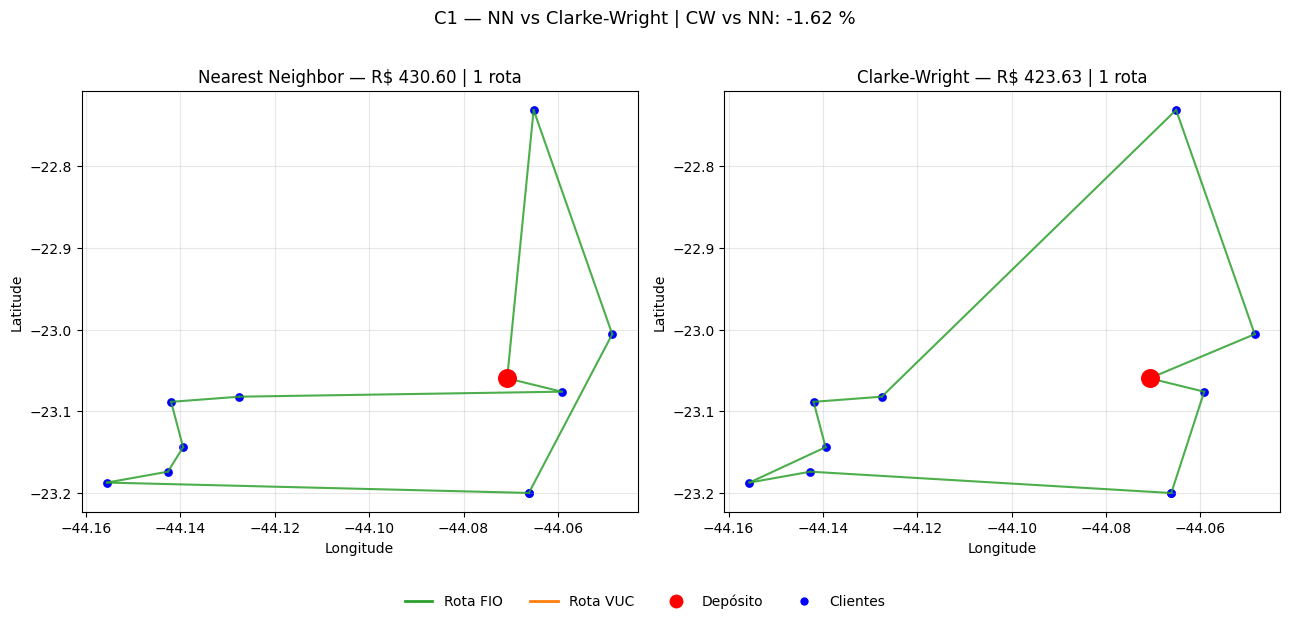

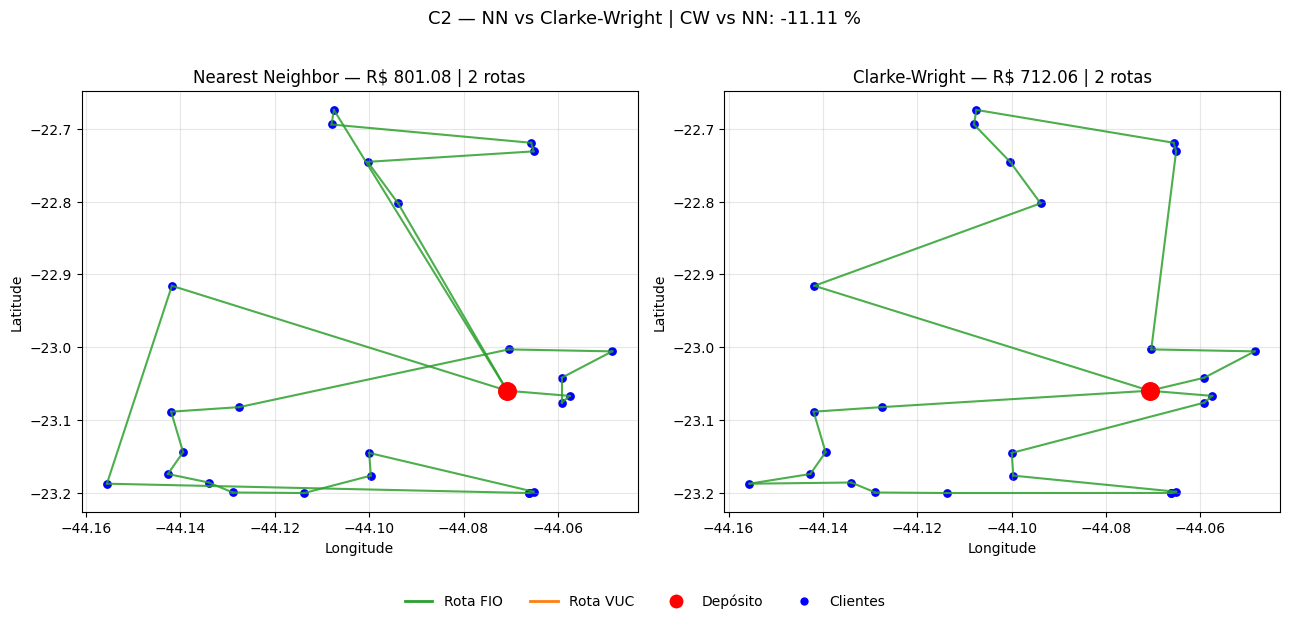

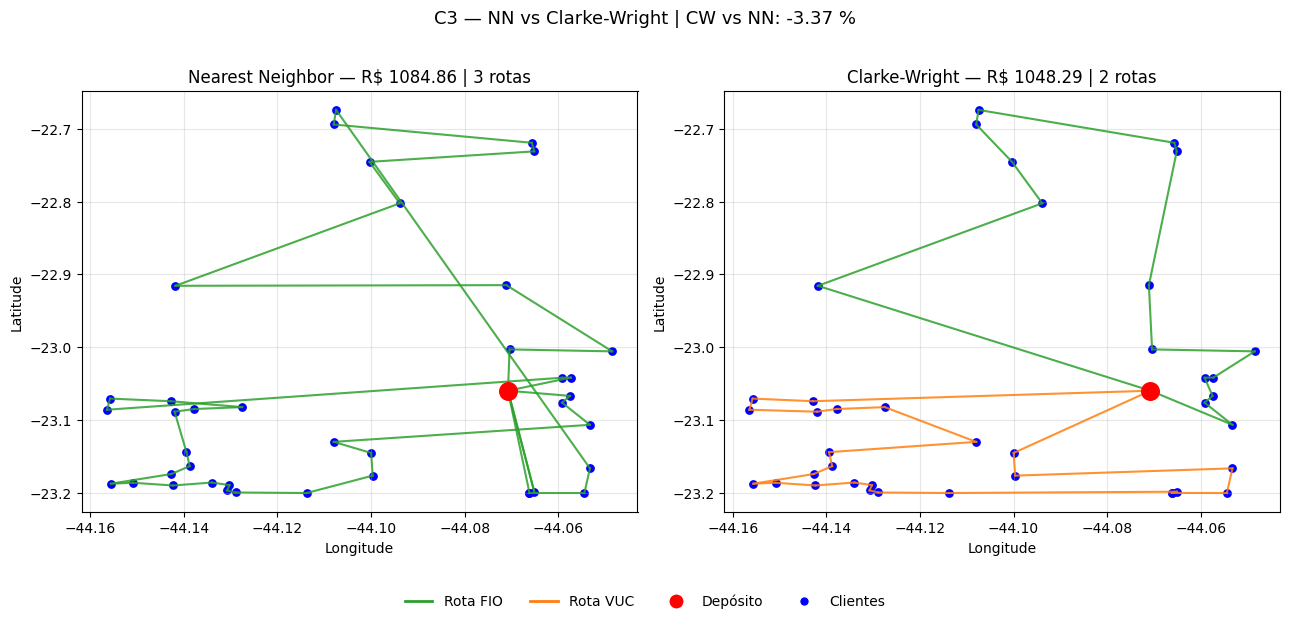

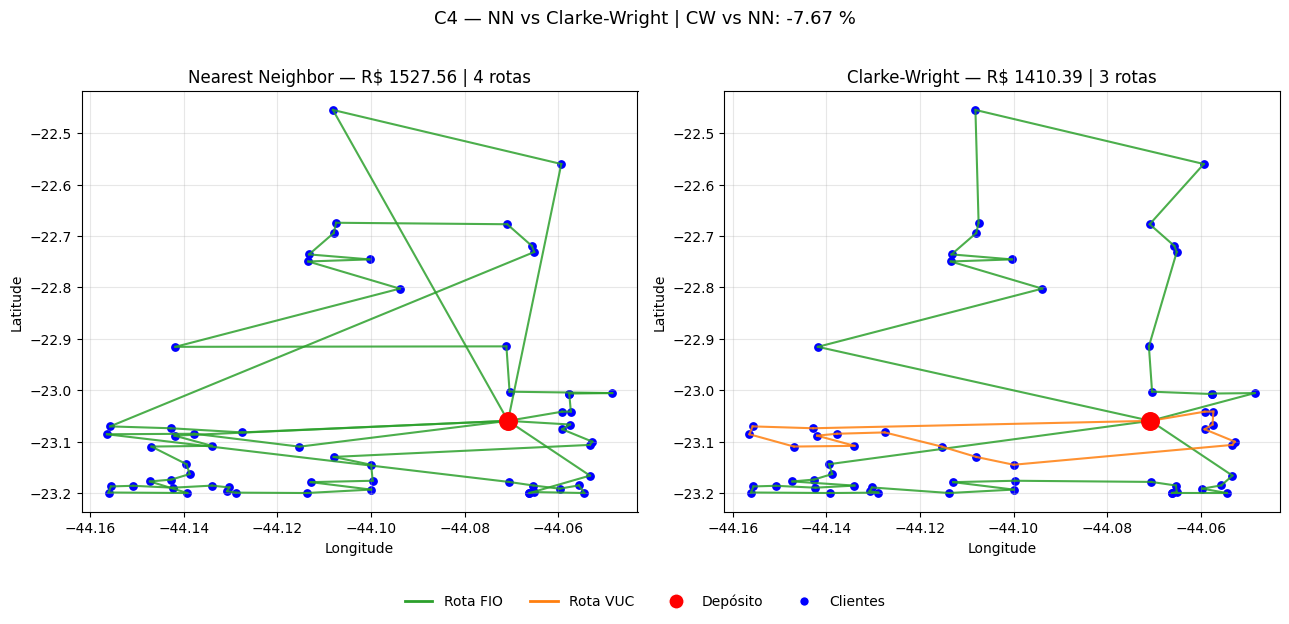

In [16]:
from matplotlib.lines import Line2D


def plot_solution(ax, solution, nodes, title):
    x_coords = nodes["lon"].values
    y_coords = nodes["lat"].values
    ax.scatter(x_coords[1:], y_coords[1:], color="blue", s=28)
    ax.scatter(x_coords[0], y_coords[0], color="red", s=160, zorder=5)
    for item in solution:
        route = item["route"]
        color = "tab:orange" if item["vehicle"] == "VUC" else "tab:green"
        for i in range(len(route) - 1):
            a, b = route[i], route[i + 1]
            ax.plot(
                [x_coords[a], x_coords[b]],
                [y_coords[a], y_coords[b]],
                color=color, linewidth=1.5, alpha=0.85,
            )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.3)


legend_handles = [
    Line2D([0], [0], color="tab:green", lw=2, label="Rota FIO"),
    Line2D([0], [0], color="tab:orange", lw=2, label="Rota VUC"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markersize=11, label="Depósito"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="blue", markersize=7, label="Clientes"),
]

for name in INSTANCIAS:
    nodes_inst = INST[name]["nodes"]
    sol_nn = results["NN"][name]["total_cost"]["solution"]
    sol_cw = results["CW"][name]["total_cost"]["solution"]
    custo_nn = results["NN"][name]["total_cost"]["metrics"]["total_cost_rs"]
    custo_cw = results["CW"][name]["total_cost"]["metrics"]["total_cost_rs"]
    delta_pct = 100 * (custo_cw - custo_nn) / custo_nn

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    fig.suptitle(
        f"{name} — NN vs Clarke-Wright | CW vs NN: {delta_pct:+.2f} %",
        fontsize=13, y=1.02,
    )
    plot_solution(
        axes[0], sol_nn, nodes_inst,
        f"Nearest Neighbor — R$ {custo_nn:.2f} | {len(sol_nn)} rota{'s' if len(sol_nn) > 1 else ''}",
    )
    plot_solution(
        axes[1], sol_cw, nodes_inst,
        f"Clarke-Wright — R$ {custo_cw:.2f} | {len(sol_cw)} rota{'s' if len(sol_cw) > 1 else ''}",
    )
    fig.legend(
        handles=legend_handles, loc="upper center", ncol=4,
        bbox_to_anchor=(0.5, -0.02), frameon=False,
    )
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f"rotas_{name}_NN_vs_CW.png", dpi=140, bbox_inches="tight")
    plt.show()

Uma figura por instância isola a comparação NN vs CW no mesmo eixo geográfico — o ponto da seção é a diferença espacial entre as duas heurísticas, não o panorama agregado das quatro. A leitura espacial corrobora as métricas numéricas em cada caso.

Em C1 (figura `rotas_C1_NN_vs_CW.png`) os dois algoritmos chegam a soluções praticamente equivalentes, com pequenas diferenças de ordenamento na rota única que conecta os 10 clientes. Em C2 (`rotas_C2_NN_vs_CW.png`) a vantagem geométrica do CW é nítida: as duas rotas Fiorino delimitam regiões compactas, enquanto o NN deixa um conjunto de cruzamentos que pioram a distância total em quase 60 km. Em C3 (`rotas_C3_NN_vs_CW.png`) o CW separa a malha em duas áreas geograficamente coerentes — Fiorino atende a região norte (verde) e VUC consolida a região sul mais densa (laranja); o NN, ao contrário, gera três rotas com bastante sobreposição na zona central, indicando decisões locais que penalizam o agrupamento global. Em C4 (`rotas_C4_NN_vs_CW.png`) o padrão se mantém: o CW divide a malha em zonas e usa o VUC para a região mais consolidada, enquanto o NN exibe vários trechos longos atravessando o cluster denso para alcançar clientes isolados — o que corresponde à rota-resíduo de 135 km identificada na análise numérica.

## 12. Diagnóstico da restrição de jornada

A pergunta 7 do Sprint Planning #2 ("Quantas rotas ficaram próximas ao limite da jornada?") motiva esta análise: contamos rotas por faixa de tempo e calculamos a folga média em relação ao limite de 8 h. Definimos "próxima ao limite" como tempo total acima de 7 h (folga ≤ 1 h).

In [17]:
linhas_jornada = []
for heur in ["NN", "CW"]:
    for name in INSTANCIAS:
        sol = results[heur][name]["total_cost"]["solution"]
        for item in sol:
            linhas_jornada.append({
                "heuristica": heur,
                "instancia": name,
                "rota_id": item["route_id"],
                "veiculo": item["vehicle"],
                "n_clientes": item["n_clients"],
                "tempo_h": round(item["total_time_h"], 2),
                "folga_h": round(H - item["total_time_h"], 2),
                "categoria": (
                    "próxima do limite (> 7 h)" if item["total_time_h"] > 7
                    else "média (4-7 h)" if item["total_time_h"] >= 4
                    else "folgada (< 4 h)"
                ),
            })

df_jornada = pd.DataFrame(linhas_jornada)
resumo_jornada = df_jornada.groupby(["heuristica", "categoria"]).size().unstack(fill_value=0)
print("Distribuição de rotas por faixa de tempo (limite H = 8 h)\n")
print(resumo_jornada.to_string())
print("\nDetalhe das rotas próximas do limite (> 7 h):\n")
print(df_jornada[df_jornada["tempo_h"] > 7].to_string(index=False))

Distribuição de rotas por faixa de tempo (limite H = 8 h)

categoria   folgada (< 4 h)  média (4-7 h)  próxima do limite (> 7 h)
heuristica                                                           
CW                        0              5                          3
NN                        3              3                          4

Detalhe das rotas próximas do limite (> 7 h):

heuristica instancia  rota_id veiculo  n_clientes  tempo_h  folga_h                 categoria
        NN        C2        1     FIO          19     7.50     0.50 próxima do limite (> 7 h)
        NN        C3        1     FIO          25     7.70     0.30 próxima do limite (> 7 h)
        NN        C4        1     FIO          26     7.84     0.16 próxima do limite (> 7 h)
        NN        C4        2     FIO          20     7.86     0.14 próxima do limite (> 7 h)
        CW        C3        1     VUC          25     7.82     0.18 próxima do limite (> 7 h)
        CW        C4        1     FIO          26

Sete das dezoito rotas geradas pelos dois algoritmos operam acima de 7 h, com folgas pequenas — de 0,13 h (8 minutos) em C4 a 0,50 h em C2. Nenhuma rota viola o limite de 8 h, mas a margem é apertada nas instâncias maiores. O NN é mais agressivo no preenchimento de rotas (quatro rotas próximas do limite contra três do CW) porque seu critério guloso de inserção continua adicionando clientes enquanto houver folga suficiente para o retorno; o CW, ao operar por fusão de rotas pequenas, tende a parar antes — fusões que aproximariam demais o tempo de 8 h são rejeitadas mesmo quando o saving seria atrativo, o que confirma a observação do slide 18 da Aula 7B sobre fusões bloqueadas por restrições operacionais.

Essa diferença de comportamento explica diretamente a fragmentação observada na seção 6.1: as rotas-resíduo do NN (1 cliente em 30,84 km em C3, 2 clientes em 135,67 km em C4) não são acidente algorítmico, mas consequência mecânica do crescimento sequencial sob jornada de 8 h. A primeira rota cresce até esbarrar no teto de capacidade ou de tempo e fecha; os clientes remanescentes — invariavelmente os geograficamente menos convenientes, porque os próximos do depósito já foram absorvidos — herdam as rotas seguintes, que precisam percorrer longas travessias para alcançá-los. O número de rotas folgadas (< 4 h) é três no NN e zero no CW, evidenciando o mesmo desbalanceamento por outra ótica: enquanto o NN exaure cada rota antes de abrir a próxima, o CW distribui carga horária mais uniformemente entre rotas via fusões controladas pelo saving, sem deixar resíduo.

### 12.1 Identificação dos clientes e regiões críticos

A categoria "próxima do limite" agrega rotas — não identifica os clientes que tornam a restrição binding. Esta subseção desce ao nível de cliente para responder às atividades 8 e 14 do Sprint Planning 2: *quais clientes ou regiões parecem tornar a restrição mais crítica?* e *há clientes que praticamente "forçam" o uso do VUC?* Para cada rota com tempo total acima de 7 h, listamos os clientes que ela atende com `id`, `CEP`, latitude/longitude e demanda. Em seguida, identificamos clusters geográficos recorrentes — CEPs e faixas de latitude/longitude que aparecem repetidamente em rotas próximas do limite.

In [2]:
import json
import pandas as pd
from collections import Counter
from pathlib import Path

DATASETS_DIR = Path("../../2/datasets")
SOLUTIONS_DIR = Path("files")
SIZES = {"C1": 10, "C2": 25, "C3": 40, "C4": 60}

nodes_by_inst = {
    name: pd.read_csv(DATASETS_DIR / f"Equipe_2_{name}_{SIZES[name]}" / "nodes.csv")
    for name in SIZES
}

linhas_clientes_criticos = []
for heur in ["nn", "cw"]:
    for name in SIZES:
        path = SOLUTIONS_DIR / f"solution_{heur}_het_{name}_total_cost.json"
        payload = json.loads(path.read_text(encoding="utf-8"))
        nodes = nodes_by_inst[name]
        for item in payload["solution"]:
            tempo_h = item.get("total_time_h")
            if tempo_h is None or tempo_h <= 7:
                continue
            for cid in item["route"]:
                if cid == 0:
                    continue
                row = nodes[nodes["id"] == cid].iloc[0]
                linhas_clientes_criticos.append({
                    "heur": heur.upper(),
                    "inst": name,
                    "rota": item["route_id"],
                    "veic": item["vehicle"],
                    "tempo_rota (h)": round(tempo_h, 2),
                    "cliente_id": int(cid),
                    "CEP": int(row["CEP"]),
                    "lat": round(row["lat"], 4),
                    "lon": round(row["lon"], 4),
                    "demanda (kg)": round(row["demanda_kg"], 1),
                })

df_criticos = pd.DataFrame(linhas_clientes_criticos)
print(f"Clientes em rotas com tempo > 7 h: {len(df_criticos)} ocorrências, "
      f"{df_criticos['cliente_id'].nunique()} clientes distintos.\n")

cep_prefixos = df_criticos["CEP"].astype(str).str[:5].value_counts().head(8)
print("Top-8 prefixos de CEP (5 dígitos) em rotas críticas:\n")
print(cep_prefixos.to_string())

Clientes em rotas com tempo > 7 h: 158 ocorrências, 59 clientes distintos.

Top-8 prefixos de CEP (5 dígitos) em rotas críticas:

CEP
25931    6
23530    6
25520    6
21210    5
21020    5
21530    5
21830    5
22720    5


As 158 ocorrências em rotas críticas (tempo > 7 h) envolvem 59 clientes distintos, com concentração em três faixas de CEP: **25xxx** (Magé, Belford Roxo, Duque de Caxias — Baixada Fluminense ao norte do depósito), **21xxx** (Bangu, Realengo, Padre Miguel — Zona Oeste do Rio ao sul) e **22xxx-23xxx** (Bangu/Santa Cruz, Zona Oeste extrema). Os CEPs 25931 (Magé, 6 ocorrências), 23530 (Bangu, 6 ocorrências) e 25520 (Magé, 6 ocorrências) são os mais recorrentes — três regiões periféricas que combinam distância e tempo de serviço suficiente para estreitar a folga da jornada. O depósito da Prolog em Caxias (CEP 25251-560) fica entre essas três faixas: rotas que tentam consolidar clientes em mais de uma delas tipicamente esgotam o tempo, justificando a fragmentação observada.

A célula seguinte identifica os clientes específicos que aparecem nas rotas VUC do CW — aquelas em que o algoritmo escolheu o veículo maior **forçado pela jornada** (capacidade utilizada de apenas ~26 %, conforme análise da Aula 8 seção 9.1). Esses clusters são os candidatos mais diretos a "forçar" o uso do VUC: sua combinação geográfica produz uma rota cuja consolidação em FIO violaria as 8 h.

In [3]:
linhas_vuc = []
for name in ["C3", "C4"]:
    path = SOLUTIONS_DIR / f"solution_cw_het_{name}_total_cost.json"
    payload = json.loads(path.read_text(encoding="utf-8"))
    nodes = nodes_by_inst[name]
    for item in payload["solution"]:
        if item["vehicle"] != "VUC":
            continue
        for cid in item["route"]:
            if cid == 0:
                continue
            row = nodes[nodes["id"] == cid].iloc[0]
            linhas_vuc.append({
                "instância": name,
                "rota_VUC": item["route_id"],
                "tempo_h": round(item["total_time_h"], 2),
                "cliente_id": int(cid),
                "CEP": int(row["CEP"]),
                "lat": round(row["lat"], 4),
                "lon": round(row["lon"], 4),
                "demanda (kg)": round(row["demanda_kg"], 1),
            })

df_vuc = pd.DataFrame(linhas_vuc)
resumo_vuc = (df_vuc.groupby("instância")
              .agg(n_clientes=("cliente_id", "nunique"),
                   demanda_total_kg=("demanda (kg)", "sum"),
                   tempo_rota_h=("tempo_h", "first"),
                   lat_min=("lat", "min"),
                   lat_max=("lat", "max"),
                   lon_min=("lon", "min"),
                   lon_max=("lon", "max")))
print("Resumo das rotas VUC (forçadas pela jornada, capacidade utilizada ~26 %):\n")
print(resumo_vuc.to_string())
print("\nClientes nas rotas VUC do CW (C3 e C4):\n")
print(df_vuc.sort_values(["instância", "lat"]).to_string(index=False))

Resumo das rotas VUC (forçadas pela jornada, capacidade utilizada ~26 %):

           n_clientes  demanda_total_kg  tempo_rota_h  lat_min  lat_max  lon_min  lon_max
instância                                                                                
C3                 25             788.0          7.82  -23.200 -23.0704 -44.1564 -44.0532
C4                 17             769.1          5.32  -23.145 -23.0416 -44.1564 -44.0527

Clientes nas rotas VUC do CW (C3 e C4):

instância  rota_VUC  tempo_h  cliente_id      CEP      lat      lon  demanda (kg)
       C3         1     7.82          14 22720000 -23.2000 -44.1138           3.5
       C3         1     7.82           1 25520000 -23.2000 -44.0662           4.6
       C3         1     7.82          37 26210000 -23.2000 -44.0544           9.2
       C3         1     7.82           7 25520001 -23.1999 -44.0662           3.0
       C3         1     7.82          25 21830008 -23.1993 -44.1289           1.4
       C3         1     7.82   

O recorte das duas rotas VUC do CW expõe geograficamente o cluster que torna o veículo maior preferível. Em C3, a rota VUC concentra 25 clientes em latitudes -23,20 a -23,07 — todos a **sul do depósito** (Caxias, lat -23,06), cobrindo a Zona Oeste do Rio (Bangu, Realengo, Padre Miguel, Santa Cruz) e parte da Baixada (Magé). Em C4, a rota VUC tem 17 clientes na faixa -23,145 a -23,04, recorte parcial do mesmo cluster acrescido de Caxias propriamente dito. A demanda consolidada em ambos os casos ultrapassa o limite do Fiorino — 788,0 kg em C3 e 769,1 kg em C4, contra os 650 kg do FIO —, tornando a partição infactível para o veículo menor sem fragmentação adicional. A leitura operacional é: a Prolog tem um **cluster sul-oeste relativamente compacto e denso em demanda** cuja consolidação em uma única visita é mais econômica via VUC.

Clientes específicos que **forçam estruturalmente o VUC** são aqueles cuja remoção da rota traria o total para baixo do limite FIO. Em C4, o cliente 60 (CEP 26311110, lat -23,10, demanda 206,0 kg) sozinho representa 26,8 % da carga da rota VUC — sua remoção reduziria o total para 563,1 kg, abaixo de 650 kg. O cliente 57 (CEP 22631002, 149,6 kg) também é candidato natural: sem ele a carga cai para 619,5 kg. Em C3, o cliente 27 (CEP 26280376, 153,6 kg), o 17 (CEP 25580020, 78,0 kg), o 22 (CEP 23550265, 66,0 kg), o 39 (66,6 kg) e o 13 (59,8 kg) compõem 423,9 kg dos 788,0 kg da rota — basta remover dois ou três deles para que o restante caiba em FIO. Esses cinco clientes em C3 e dois em C4 são as **demandas-âncora** do regime VUC; a operação real da Prolog deve atentar para mudanças nas suas demandas (revisão de pedidos, promoções) porque pequenas variações nelas movem a fronteira VUC × FIO da decisão de frota.

## 13. Persistência das soluções para a Aula 8

As soluções iniciais geradas aqui servem de ponto de partida para as heurísticas de busca local (2-opt e relocate) da Aula 8. Salvamos em `files/` um JSON por combinação heurística × instância × critério, preservando a sequência de rotas, o veículo escolhido e as métricas por rota.

In [18]:
def _python_safe(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {k: _python_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_python_safe(v) for v in obj]
    return obj


arquivos_salvos = []
for heur in ["NN", "CW"]:
    for name in INSTANCIAS:
        for crit in CRITERIOS:
            payload = {
                "heuristic": heur,
                "instance": name,
                "criterion": crit,
                "solution": _python_safe(results[heur][name][crit]["solution"]),
                "metrics": _python_safe(results[heur][name][crit]["metrics"]),
                "elapsed_s": results[heur][name][crit]["elapsed_s"],
            }
            fname = f"solution_{heur.lower()}_het_{name}_{crit}.json"
            (OUTPUT_FILES_DIR / fname).write_text(
                json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8",
            )
            arquivos_salvos.append(fname)

print(f"{len(arquivos_salvos)} arquivos salvos em {OUTPUT_FILES_DIR.resolve()}:")
for fname in arquivos_salvos:
    print("  -", fname)

16 arquivos salvos em C:\Users\rodri\OneDrive\Documentos\Claude\Cowork\Proj. Distribuição Fisica\Aulas\7\Aula7_Heuristicas_Construtivas\files:
  - solution_nn_het_C1_total_cost.json
  - solution_nn_het_C1_cost_per_client.json
  - solution_nn_het_C2_total_cost.json
  - solution_nn_het_C2_cost_per_client.json
  - solution_nn_het_C3_total_cost.json
  - solution_nn_het_C3_cost_per_client.json
  - solution_nn_het_C4_total_cost.json
  - solution_nn_het_C4_cost_per_client.json
  - solution_cw_het_C1_total_cost.json
  - solution_cw_het_C1_cost_per_client.json
  - solution_cw_het_C2_total_cost.json
  - solution_cw_het_C2_cost_per_client.json
  - solution_cw_het_C3_total_cost.json
  - solution_cw_het_C3_cost_per_client.json
  - solution_cw_het_C4_total_cost.json
  - solution_cw_het_C4_cost_per_client.json
